# 2.6 Applications

CUTE provides a compact representation for a set of layouts that is strictly larger than can be represented with traditional flat shapes and strides. In contrast, libraries like CUTLASS v2 implement each layout individually and manually. This approach is labor-intensive, error-prone, and requires significant development time. To illustrate the complexity, the CUTLASS v2 code base contains nearly 300 separately implemented layouts spread across 87 files, collectively amounting to approximately 55,000 lines of code. Furthermore, many algorithms in CUTLASS v2 are designed to operate with only a limited subset of these layouts, exacerbating maintenance and scalability challenges. By comparison, CUTE's core layout representation, along with the associated algebra for manipulating layouts, requires only 3,000 lines of code and is capable of representing all 300 layouts found in CUTLASS v2 and more. Algorithms implemented in CUTE can enforce constraints on the rank or shape of their input, but remain compatible with any layout that satisfies these preconditions. This decoupling of algorithm logic from specific data or thread layouts results in more flexible and composable code.

The benefits above were recognized and CUTE now forms the basis of CUTLASS v3, CUTLASS v4, and CuTe DSL, which are all built on top of CUTE's core layout representation and algebra. The complex data layouts and partitioning patterns required by modern tensor instructions are represented and manipulated with CUTE's single, consistent, and composable representation that has been robust across multiple generations of NVIDIA's instruction set architecture.

In this section, we detail the use of only the layout and tensor representation to provide powerful generic implementations of two of the most fundamental algorithms: COPY and GEMM. These algorithms are implemented with CUTE tensors and are used to illustrate logical implementations being applicable to a wide range of applications. These algorithms, though often optimal on their own, serve as excellent generic reference implementations for optimized versions. The layout algebra in Section 3 provides methods for inspecting and manipulating layouts to perform these optimizations.

In [1]:
from tensor_layouts import *
from tensor_layouts.viz import draw_layout, draw_mma_layout

## 2.6.1 COPY

A generic COPY algorithm written with CUTE tensors is

```python
# @pre size(src) == size(dst)
def copy(src : Tensor,       # N
         dst : Tensor):       # N
    for i in range(size(dst)):
        dst[i] = src[i]
```

where the precondition specifies that the size of the tensors is equal. Equivalently written in the tensor argument comments, both tensors are compatible with a shape N.

This simple implementation of COPY accommodates a wide range of applications by varying the layouts of the source and destination tensors. Table 2 provides examples of common applications and their associated source and destination layouts.

| Application | Source Layout | Destination Layout |
|---|---|---|
| 1D Arrays | $8 : 1$ | $8 : 1$ |
| ND Arrays | $(8, 2, 3) : (1, 16, 32)$ | $(8, 2, 3) : (1, 16, 32)$ |
| Gather | $(2, 3, 2) : (42, 1, 128)$ | $12 : 1$ |
| Scatter | $12 : 1$ | $(2, 3, 2) : (42, 1, 128)$ |
| Broadcast | $7 : 0$ | $7 : 1$ |
| Constant | $7 : 0$ | $7 : 0$ |
| Transpose | $(8, 3) : (1, 8)$ | $(8, 3) : (3, 1)$ |
| Tensor Transpose | $(8, (3, 5)) : (1, (57, 8))$ | $(8, 15) : (1, 8)$ |

In [2]:
# Implement the generic COPY matching the paper's pseudocode.
# Tensor[i] with a single integer does flat 1D evaluation through
# idx2crd, matching CuTe C++ Tensor::operator()(int).

def copy(src: Tensor, dst: Tensor):
    """Generic COPY: dst[i] = src[i] for all i in the flat index space."""
    assert size(src.layout) == size(dst.layout)
    for i in range(size(dst.layout)):
        dst[i] = src[i]

In [3]:
# 1D Arrays: 8:1 -> 8:1  (simple contiguous copy)
src = Tensor(Layout(8, 1), data=list(range(10, 18)))
dst = Tensor(Layout(8, 1), data=[0] * 8)

copy(src, dst)
assert dst.data == src.data
print(f"1D Arrays:  src={src.data}")
print(f"            dst={dst.data}")

1D Arrays:  src=[10, 11, 12, 13, 14, 15, 16, 17]
            dst=[10, 11, 12, 13, 14, 15, 16, 17]


In [4]:
# Gather: (2,3,2):(42,1,128) -> 12:1
# Gather reads from scattered locations into contiguous memory.
src_layout = Layout((2, 3, 2), (42, 1, 128))
dst_layout = Layout(12, 1)

src = Tensor(src_layout, data=[f"x{i}" for i in range(cosize(src_layout))])
dst = Tensor(dst_layout, data=[None] * 12)

copy(src, dst)
print(f"Gather: src offsets = {[src_layout(i) for i in range(12)]}")
print(f"        dst = {dst.data}")

for i in range(12):
    assert dst.data[i] == src.data[src_layout(i)]

Gather: src offsets = [0, 42, 1, 43, 2, 44, 128, 170, 129, 171, 130, 172]
        dst = ['x0', 'x42', 'x1', 'x43', 'x2', 'x44', 'x128', 'x170', 'x129', 'x171', 'x130', 'x172']


In [5]:
# Scatter: 12:1 -> (2,3,2):(42,1,128)
# Scatter writes contiguous data to scattered locations.
src_layout = Layout(12, 1)
dst_layout = Layout((2, 3, 2), (42, 1, 128))

src = Tensor(src_layout, data=[f"v{i}" for i in range(12)])
dst = Tensor(dst_layout, data=[None] * cosize(dst_layout))

copy(src, dst)
print(f"Scatter: dst offsets = {[dst_layout(i) for i in range(12)]}")
print(f"         values at those offsets: {[dst.data[dst_layout(i)] for i in range(12)]}")

for i in range(12):
    assert dst.data[dst_layout(i)] == src.data[i]

Scatter: dst offsets = [0, 42, 1, 43, 2, 44, 128, 170, 129, 171, 130, 172]
         values at those offsets: ['v0', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11']


In [6]:
# Broadcast: 7:0 -> 7:1
# A stride of 0 means every logical element maps to the same physical element.
src = Tensor(Layout(7, 0), data=[42])  # one physical element
dst = Tensor(Layout(7, 1), data=[0] * 7)

copy(src, dst)
print(f"Broadcast: src has 1 element = {src.data[0]}")
print(f"           dst = {dst.data}")
assert dst.data == [42] * 7

Broadcast: src has 1 element = 42
           dst = [42, 42, 42, 42, 42, 42, 42]


In [7]:
# Transpose: (8,3):(1,8) -> (8,3):(3,1)
# Column-major to row-major.
src_layout = Layout((8, 3), (1, 8))
dst_layout = Layout((8, 3), (3, 1))

src = Tensor(src_layout, data=list(range(24)))
dst = Tensor(dst_layout, data=[0] * 24)

copy(src, dst)

for i in range(8):
    for j in range(3):
        assert dst.data[dst_layout(i, j)] == src.data[src_layout(i, j)]

print("Transpose (column-major -> row-major):")
print(f"  src layout: {src_layout}")
print(f"  dst layout: {dst_layout}")
print(f"  src[2,1] at offset {src_layout(2,1)} = {src.data[src_layout(2,1)]}")
print(f"  dst[2,1] at offset {dst_layout(2,1)} = {dst.data[dst_layout(2,1)]}")
assert src.data[src_layout(2,1)] == dst.data[dst_layout(2,1)]

Transpose (column-major -> row-major):
  src layout: (8, 3) : (1, 8)
  dst layout: (8, 3) : (3, 1)
  src[2,1] at offset 10 = 10
  dst[2,1] at offset 7 = 10


Source layout (column-major): (8,3):(1,8)


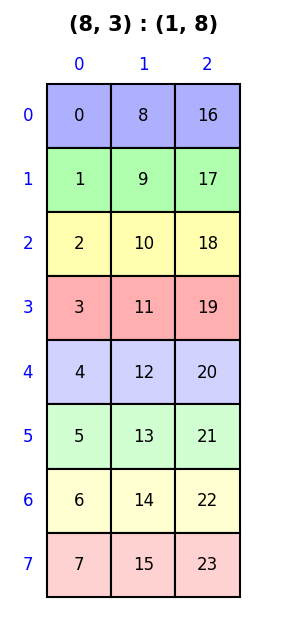


Destination layout (row-major): (8,3):(3,1)


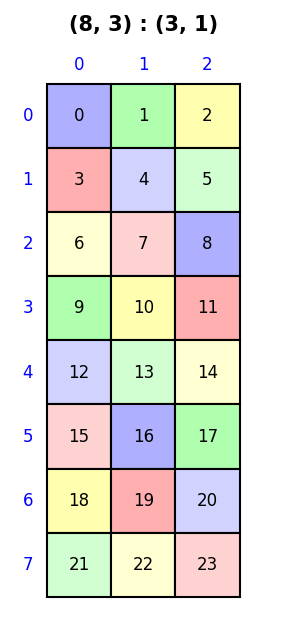

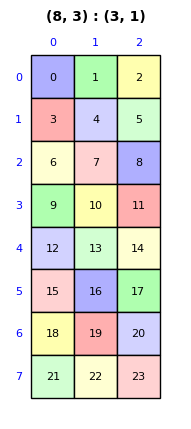

In [8]:
# Visualize the transpose: source (col-major) vs destination (row-major)
print("Source layout (column-major): (8,3):(1,8)")
draw_layout(src_layout, colorize=True)

print("\nDestination layout (row-major): (8,3):(3,1)")
draw_layout(dst_layout, colorize=True)

Any tensor of any rank can be copied to any tensor of any other rank. In that sense, COPY is a rank-1 algorithm regardless of the arguments' ranks. This is a version of rank-agnostic programming.

When the `idx2crd` function for the source and destination tensors is computationally inexpensive to evaluate (e.g., when the tensor shapes are statically known), the above implementation never actually generates dynamic coordinate transformations. In such cases, the loop can be unrolled, `idx2crd` can be statically applied to the loop index `i`, and the `inner_product` computation incurs minimal overhead in computing offsets. This is a version of static analysis and optimization since the layout shape and/or strides are often known at compile-time and available to the compiler. If `idx2crd` does incur a runtime cost, the provided implementation still serves as a robust reference to validate optimized versions that may further inspect domains and transform layouts using operations detailed in Section 3.

## 2.6.2 GEMM

A generic GEMM algorithm written with CUTE tensors is

```python
# @pre M: size[0](A) == size[0](C)
# @pre N: size[0](B) == size[1](C)
# @pre K: size[1](A) == size[1](B)
def gemm(A : Tensor,       # (M,K)
         B : Tensor,       # (N,K)
         C : Tensor):      # (M,N)
    for k in range(size[1](B)):
        for n in range(size[0](B)):
            for m in range(size[0](A)):
                C[m,n] += A[m,k] * B[n,k]
```

where the precondition specifies the logical constraints of the GEMM algorithm. In the comments of each tensor parameter, we write the shape that each tensor must be compatible with.

This simple implementation of GEMM (and a batched-GEMM extension) can encompass a variety of applications by varying the layouts of the tensors. In Table 3, some common applications and example layouts are shown. These include all of the N-T variants of the BLAS GEMM and the generically strided (dm*, dn*, dk*) variants of the BLIS GEMM. This also functions as a fully generic tensor-tensor contraction (GETT) where the tensors are folded into the appropriate matrix shape by grouping logical row modes, column modes, reduction modes, and batched modes. Creating a layout (as a functional composition of CUTE layouts) that implements the im2col transformation also allows GEMM to implement CONV, which is core to many modern machine learning applications.

| Application | A-Layout | B-Layout | C-Layout |
|---|---|---|---|
| NT GEMM | $(M, K) : (1, \text{lda})$ | $(N, K) : (1, \text{ldb})$ | $(M, N) : (1, \text{ldc})$ |
| TN GEMM | $(M, K) : (\text{lda}, 1)$ | $(N, K) : (\text{ldb}, 1)$ | $(M, N) : (1, \text{ldc})$ |
| NTT GEMM | $(N, K) : (1, \text{ldb})$ | $(M, K) : (1, \text{lda})$ | $(N, M) : (1, \text{ldc})$ |
| BLIS GEMM | $(M, K) : (\text{dma}, \text{dka})$ | $(N, K) : (\text{dnb}, \text{dkb})$ | $(M, N) : (\text{dmc}, \text{dnc})$ |
| GETT | $((M_1, M_2), K) : ((1, W), X)$ | $(N, K) : (K, 1)$ | $((M_1, M_2), N) : ((1, Y), Z)$ |
| GETT | $(M, (K_1, K_2)) : ((W, X), 1)$ | $(N, (K_1, K_2)) : ((Y, Z), 1)$ | $(M, N) : (1, M)$ |
| CONV | $(K, (C, T, R, S)) : D_A$ | $((N, Z, P, Q), (C, T, R, S)) : D_B$ | $(K, (N, Z, P, Q)) : D_C$ |

By abstracting the fused-multiply-add operation and providing sufficiently powerful tiling utilities, this algorithm can be adapted and applied recursively at each level of an architectural hierarchy.

In [9]:
# Implement the generic GEMM matching the paper's pseudocode.
# A, B, C are Tensors with data.  A is (M,K), B is (N,K), C is (M,N).
# Since all coordinates are fully specified, Tensor[m,k] returns the data
# value and Tensor[m,n] = val writes it — so C[m,n] += A[m,k] * B[n,k]
# works directly.

def gemm(A: Tensor, B: Tensor, C: Tensor):
    """Generic GEMM: C += A * B^T via layouts."""
    M = size(mode(A.layout, 0))
    N = size(mode(B.layout, 0))
    K = size(mode(A.layout, 1))
    assert M == size(mode(C.layout, 0)), f"M mismatch"
    assert N == size(mode(C.layout, 1)), f"N mismatch"
    assert K == size(mode(B.layout, 1)), f"K mismatch"
    for k in range(K):
        for n in range(N):
            for m in range(M):
                C[m, n] += A[m, k] * B[n, k]

In [10]:
import numpy as np

# NT GEMM: A is column-major (M,K):(1,lda), B is column-major (N,K):(1,ldb)
# C is column-major (M,N):(1,ldc).  Corresponds to C = A @ B^T.
M, N, K = 4, 3, 5
lda, ldb, ldc = M, N, M

np.random.seed(42)
A_np = np.random.randn(M, K)
B_np = np.random.randn(N, K)

A = Tensor(Layout((M, K), (1, lda)), data=list(A_np.T.flatten()))
B = Tensor(Layout((N, K), (1, ldb)), data=list(B_np.T.flatten()))
C = Tensor(Layout((M, N), (1, ldc)), data=[0.0] * (M * N))

print(f"NT GEMM: M={M}, N={N}, K={K}")
print(f"  A: {A.layout}")
print(f"  B: {B.layout}")
print(f"  C: {C.layout}")

for i in range(M):
    for j in range(K):
        assert A[i, j] == A_np[i, j]

gemm(A, B, C)

C_ref = A_np @ B_np.T
C_result = np.array([[C[i, j] for j in range(N)] for i in range(M)])
assert np.allclose(C_result, C_ref)
print("\nNT GEMM result matches numpy reference!")

NT GEMM: M=4, N=3, K=5
  A: (4, 5) : (1, 4)
  B: (3, 5) : (1, 3)
  C: (4, 3) : (1, 4)

NT GEMM result matches numpy reference!


In [11]:
# TN GEMM: A is row-major (M,K):(lda,1), B is row-major (N,K):(ldb,1)
# C is column-major (M,N):(1,ldc)
lda, ldb, ldc = K, K, M

A_tn = Tensor(Layout((M, K), (lda, 1)), data=list(A_np.flatten()))
B_tn = Tensor(Layout((N, K), (ldb, 1)), data=list(B_np.flatten()))
C_tn = Tensor(Layout((M, N), (1, ldc)), data=[0.0] * (M * N))

print(f"TN GEMM: M={M}, N={N}, K={K}")
print(f"  A: {A_tn.layout}")
print(f"  B: {B_tn.layout}")
print(f"  C: {C_tn.layout}")

gemm(A_tn, B_tn, C_tn)

C_result_tn = np.array([[C_tn[i, j] for j in range(N)] for i in range(M)])
assert np.allclose(C_result_tn, C_ref)
print("\nTN GEMM result matches numpy reference!")

TN GEMM: M=4, N=3, K=5
  A: (4, 5) : (5, 1)
  B: (3, 5) : (5, 1)
  C: (4, 3) : (1, 4)

TN GEMM result matches numpy reference!


In [12]:
# GETT: tensor contraction via GEMM with hierarchical layouts.
# A has shape ((M1, M2), K) — the row mode is a multi-mode.
M1, M2, K_gett, N_gett = 3, 2, 4, 5
M_total = M1 * M2

np.random.seed(7)

A_gett = Tensor(
    Layout(((M1, M2), K_gett), ((1, M1), M1 * M2)),
    data=list(np.random.randn(M_total * K_gett)))
B_gett = Tensor(
    Layout((N_gett, K_gett), (1, N_gett)),
    data=list(np.random.randn(N_gett * K_gett)))
C_gett = Tensor(
    Layout(((M1, M2), N_gett), ((1, M1), M1 * M2)),
    data=[0.0] * (M_total * N_gett))

print(f"GETT: M=({M1},{M2})={M_total}, N={N_gett}, K={K_gett}")
print(f"  A: {A_gett.layout}")
print(f"  B: {B_gett.layout}")
print(f"  C: {C_gett.layout}")

gemm(A_gett, B_gett, C_gett)

# Reference
A_mat = np.array([[A_gett[m, k] for k in range(K_gett)]
                  for m in range(M_total)])
B_mat = np.array([[B_gett[n, k] for k in range(K_gett)]
                  for n in range(N_gett)])
C_ref_gett = A_mat @ B_mat.T
C_result_gett = np.array([[C_gett[m, n] for n in range(N_gett)]
                          for m in range(M_total)])
assert np.allclose(C_result_gett, C_ref_gett)
print("\nGETT result matches reference — hierarchical layouts work seamlessly!")

GETT: M=(3,2)=6, N=5, K=4
  A: ((3, 2), 4) : ((1, 3), 6)
  B: (5, 4) : (1, 5)
  C: ((3, 2), 5) : ((1, 3), 6)

GETT result matches reference — hierarchical layouts work seamlessly!


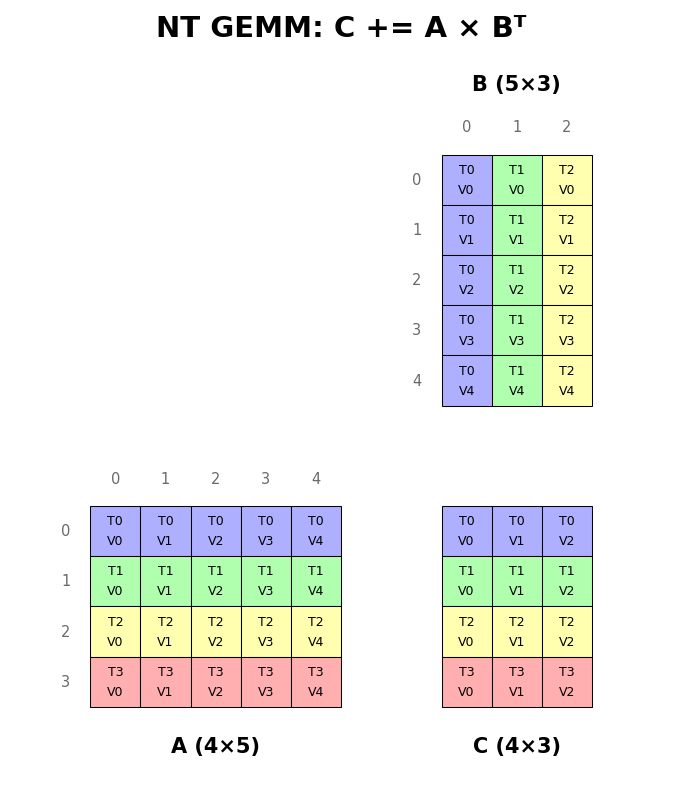

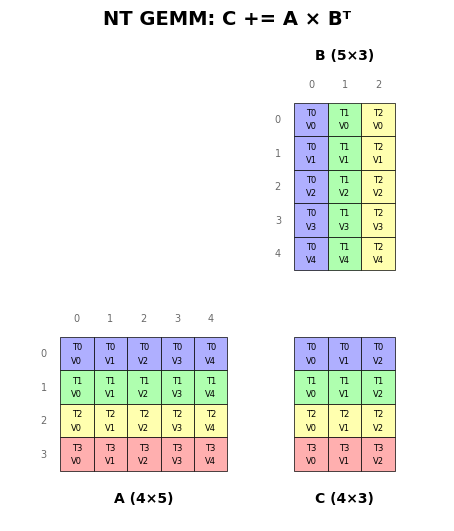

In [13]:
draw_mma_layout(
    A.layout, B.layout, C.layout,
    tile_mnk=(M, N, K),
    main_title="NT GEMM: C += A × Bᵀ",
)